# Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Inisialisasi File CSV

In [2]:
df = pd.read_csv("Indikator_Kesehatan_mhs.csv")
df.head()

,KabKot,H1. Persentase Jaminan Kesehatan,H2. Persentase Keluhan Kesehatan,H3. Persentase Kesakitan,H4. Jumlah Faskes,H5. Lama Rawat Inap,H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun,H7. Persentase ASI sampai Baduta,H8. Rasio Dokter: Kecamatan,H9. Rasio Bidan:Desa/Kelurahan,...,H30. Persentase Pneumonia per Prediksi Terindikasi,H31. Persentase Diare Mendapat Pelayanan,H32. Persentase Hipertensi Mendapat Pelayanan,H33. Persentase DM Mendapat Pelayanan,H34. Persentase ODGJ Mendapat Pelayanan,H35. Persentase Sarana Air Minum Memenuhi Syarat,H36. Persentase Jamban Sehat,H37. Persentase Desa STBM,H38. TTU Memenuhi Syarat Kesehatan,H39. TPM Memenuhi Syarat Kesehatan
0,KAB. PACITAN,36.00,17.73,9.10,120.0,4.41,4.47,92.64,2.75,2.14,...,4.0,22.4,19.6,76.7,156.2,78.5,100.0,90.1,62.3,36.4
1,KAB. PONOROGO,127.28,39.59,18.92,210.0,4.16,3.45,96.11,8.81,1.99,...,43.9,36.1,15.0,86.4,138.2,98.0,100.0,100.0,59.7,53.5
2,KAB. TRENGGALEK,45.79,43.94,18.17,128.0,4.69,4.18,94.46,22.21,2.53,...,48.8,52.4,13.3,100.0,30.6,86.6,100.0,100.0,77.2,85.9
3,KAB. TULUNGAGUNG,99.88,NaN,19.19,135.0,5.05,4.18,100.00,8.58,2.26,...,36.8,59.8,73.6,155.2,111.2,62.2,87.7,81.2,81.8,78.6
4,KAB. BLITAR,64.09,39.66,18.17,98.0,4.43,3.62,92.10,23.18,2.27,...,45.4,29.6,33.1,97.5,94.9,75.9,96.4,86.7,79.1,63.5


# Check Missing Value

In [4]:
df.isnull().sum()   

KabKot                                                0
H1. Persentase Jaminan Kesehatan                      0
H2. Persentase Keluhan Kesehatan                      3
H3. Persentase Kesakitan                              0
H4. Jumlah Faskes                                     1
H5. Lama Rawat Inap                                   4
H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun    0
H7. Persentase ASI sampai Baduta                      0
H8. Rasio Dokter: Kecamatan                           0
H9. Rasio Bidan:Desa/Kelurahan                        2
H10. Rasio Jumlah Perawat:Kecamatan                   0
H11. Angka Kematian Netto                             0
H12. Rasio Posyandu Aktif:Desa/Kelurahan              0
H13. Persentase Ibu Mati Melahirkan                   3
H14. Rata-rata Persentase Ibu Hamil Imunisasi Td      0
H15. Persentase Penanganan Neonatal                   1
H16. Jumlah Bayi Mati Neonatal                        2
H17. Persen BBLR                                

# Handling Missing Value

In [10]:
df_filled = df.fillna(df.mean(numeric_only=True))
# df_filled.head()
df_filled.isnull().sum()

KabKot                                                0
H1. Persentase Jaminan Kesehatan                      0
H2. Persentase Keluhan Kesehatan                      0
H3. Persentase Kesakitan                              0
H4. Jumlah Faskes                                     0
H5. Lama Rawat Inap                                   0
H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun    0
H7. Persentase ASI sampai Baduta                      0
H8. Rasio Dokter: Kecamatan                           0
H9. Rasio Bidan:Desa/Kelurahan                        0
H10. Rasio Jumlah Perawat:Kecamatan                   0
H11. Angka Kematian Netto                             0
H12. Rasio Posyandu Aktif:Desa/Kelurahan              0
H13. Persentase Ibu Mati Melahirkan                   0
H14. Rata-rata Persentase Ibu Hamil Imunisasi Td      0
H15. Persentase Penanganan Neonatal                   0
H16. Jumlah Bayi Mati Neonatal                        0
H17. Persen BBLR                                

# Variable X and Y

In [45]:
y = df_filled["H11. Angka Kematian Netto"]
x = df_filled[[
    "H4. Jumlah Faskes",
    "H8. Rasio Dokter: Kecamatan",
    "H9. Rasio Bidan:Desa/Kelurahan",
    "H10. Rasio Jumlah Perawat:Kecamatan",
    "H13. Persentase Ibu Mati Melahirkan",
    "H16. Jumlah Bayi Mati Neonatal",
    "H17. Persen BBLR",
    "H28. Jumlah Terduga TBC",
    "H29. Persentase Keberhasilan Pengobatan TBC",
    "H30. Persentase Pneumonia per Prediksi Terindikasi",
    "H35. Persentase Sarana Air Minum Memenuhi Syarat",
    "H36. Persentase Jamban Sehat"
]]

# Check Outlier

In [ ]:
# Cek outlier dengan metode IQR
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1
    
outlier_condition = ((x < (Q1 - 1.5 * IQR)) |
                     (x > (Q3 + 1.5 * IQR)))

print("Jumlah outlier tiap variabel:")
print(outlier_condition.sum())

Jumlah outlier tiap variabel:
H4. Jumlah Faskes                                     2
H8. Rasio Dokter: Kecamatan                           5
H9. Rasio Bidan:Desa/Kelurahan                        5
H10. Rasio Jumlah Perawat:Kecamatan                   6
H13. Persentase Ibu Mati Melahirkan                   1
H16. Jumlah Bayi Mati Neonatal                        0
H17. Persen BBLR                                      3
H28. Jumlah Terduga TBC                               3
H29. Persentase Keberhasilan Pengobatan TBC           3
H30. Persentase Pneumonia per Prediksi Terindikasi    0
H35. Persentase Sarana Air Minum Memenuhi Syarat      3
H36. Persentase Jamban Sehat                          4
dtype: int64


# Handling Outlier

In [ ]:
import numpy as np
X_winsor = x.copy()

for col in x.columns:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_winsor[col] = np.where(x[col] < lower, lower,
                             np.where(x[col] > upper, upper,
                                      x[col]))

print("=== SEBELUM WINSOR ===")
print(x.describe())

print("\n=== SESUDAH WINSOR ===")
print(X_winsor.describe())

=== SEBELUM WINSOR ===
       H4. Jumlah Faskes  H8. Rasio Dokter: Kecamatan  \
count          38.000000                    38.000000   
mean          116.189189                    68.111842   
std            66.798543                   206.817588   
min            12.000000                     2.750000   
25%            87.750000                    11.085000   
50%           112.500000                    20.495000   
75%           145.500000                    36.542500   
max           261.000000                  1270.000000   

       H9. Rasio Bidan:Desa/Kelurahan  H10. Rasio Jumlah Perawat:Kecamatan  \
count                       38.000000                            38.000000   
mean                         4.303056                           119.102632   
std                          3.052240                           133.691794   
min                          1.500000                            33.290000   
25%                          2.262500                            50.96250

# Standarisasi 

In [62]:
scaler  = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA

In [63]:
pca = PCA()
x_pca =  pca.fit_transform(x_scaled)

# Scree Plot & Explained Variance

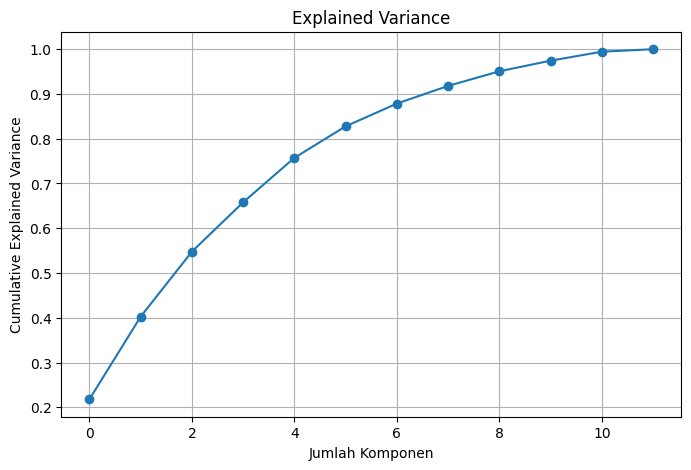

Explained Variance Ratio:
[0.21796341 0.18462344 0.14520958 0.11019335 0.09942118 0.07034767
 0.05082722 0.03942658 0.0327011  0.02371677 0.02004151 0.00552819]


In [64]:
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance")
plt.grid()
plt.show()

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# PCA Final

In [65]:
pca =  PCA(n_components=3)
x_pca =  pca.fit_transform(x_scaled)

# Interepretasi Loadings

In [66]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=x.columns
)

loadings

,PC1,PC2,PC3
H4. Jumlah Faskes,-0.175705,-0.077316,0.397264
H8. Rasio Dokter: Kecamatan,-0.390488,-0.139735,0.116644
H9. Rasio Bidan:Desa/Kelurahan,-0.356100,0.419817,-0.310792
H10. Rasio Jumlah Perawat:Kecamatan,-0.334209,0.504004,-0.185836
H13. Persentase Ibu Mati Melahirkan,-0.062534,-0.284697,-0.381261
H16. Jumlah Bayi Mati Neonatal,0.476399,-0.023860,-0.143032
H17. Persen BBLR,-0.288652,-0.356361,-0.397580
H28. Jumlah Terduga TBC,0.201099,0.283977,0.005130
H29. Persentase Keberhasilan Pengobatan TBC,0.375441,0.213840,0.114456
H30. Persentase Pneumonia per Prediksi Terindikasi,0.174505,0.317211,-0.345624


# Split Data

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    x_pca, y, test_size=0.2, random_state=42
)

# PCA REGRESI

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Koefisien:", model.coef_)
print("Intercept:", model.intercept_)

NameError: name 'X_train' is not defined

# Prediction

In [69]:
y_pred = model.predict(X_test)

# Evaluasai

In [70]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.013314453739012522
MSE: 536.6305180803625


# Plot Residuals

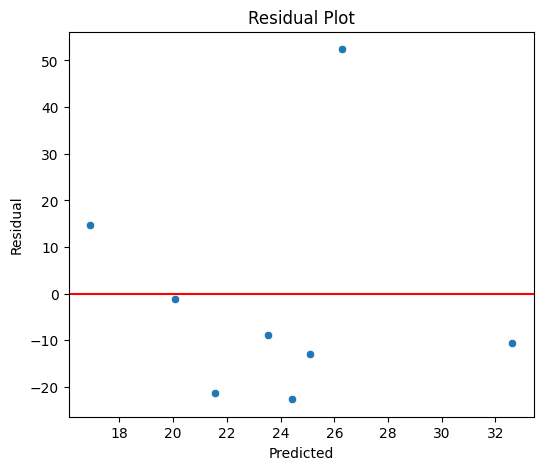

In [71]:
residual = y_test - y_pred

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residual)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

# Interepretasi

Berdasarkan hasil PCA, tiga komponen utama mampu menjelaskan lebih dari 80% variasi data.
Model PCR menghasilkan nilai R² sebesar 0.013314453739012522, yang menunjukkan bahwa model mampu menjelaskan 1.33% variasi Angka Kematian Netto.
Komponen pertama didominasi oleh variabel fasilitas kesehatan, komponen kedua oleh indikator penyakit, dan komponen ketiga oleh sanitasi.